# SMART 1 - Recopilacion de Datos
**Objetivo:** Seleccionar y cargar un dataset de Kaggle con precios de casas (minimo 200 registros).

**Dataset:** Ames Iowa Housing Dataset (1460 registros, 79 caracteristicas)

**Fecha:** Para finales de la segunda semana de julio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 1. Cargar el dataset

Opciones para obtener el dataset:
- **Opcion A:** Descargar manualmente de Kaggle y ponerlo en `data/raw/`
- **Opcion B:** Usar la API de Kaggle (requiere cuenta y token)

Link: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

In [2]:
# Opcion A: Cargar desde archivo local
# Primero descarga el dataset de Kaggle y guardalo como data/raw/train.csv

df = pd.read_csv('../data/raw/train.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Opcion B: Si usas la API de Kaggle
# pip install kaggle
# Configura tu token en ~/.kaggle/kaggle.json

# !kaggle competitions download -c house-prices-advanced-regression-techniques
# !unzip house-prices-advanced-regression-techniques.zip -d ../data/raw/

## 2. Exploracion inicial del dataset

In [4]:
# Forma del dataset (filas, columnas)
print(f'Registros: {df.shape[0]}')
print(f'Caracteristicas: {df.shape[1]}')
print(f'\nColumnas:')
print(df.columns.tolist())

Registros: 1460
Caracteristicas: 81

Columnas:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '

In [5]:
# Tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
# Estadisticas generales
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 3. Identificar la variable objetivo

La variable objetivo es **SalePrice** (precio de venta de la vivienda).

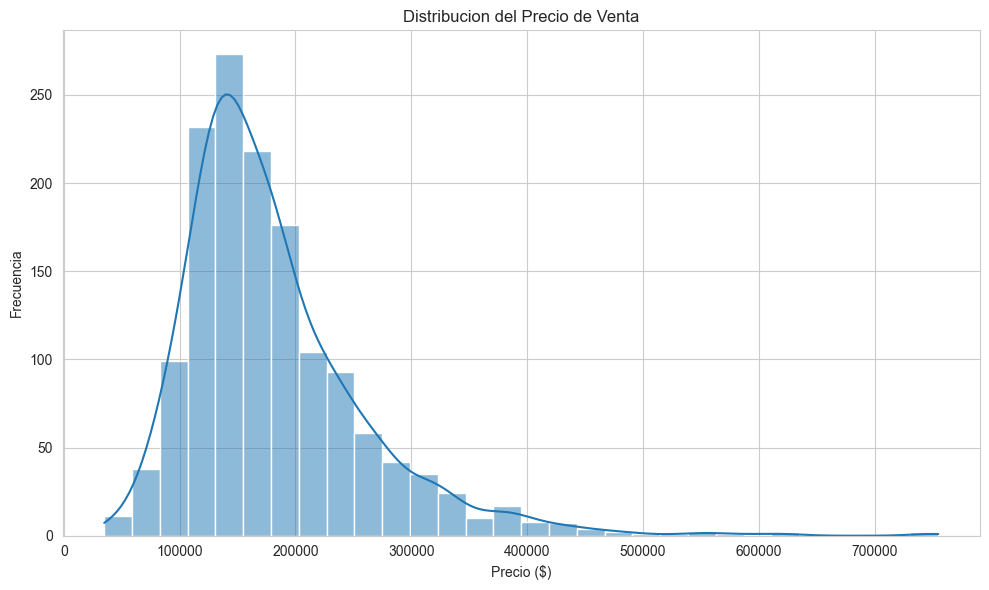


Precio minimo: $34,900
Precio maximo: $755,000
Precio promedio: $180,921
Precio mediana: $163,000


In [7]:
# Distribucion del precio de venta
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title('Distribucion del Precio de Venta')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(f'\nPrecio minimo: ${df["SalePrice"].min():,.0f}')
print(f'Precio maximo: ${df["SalePrice"].max():,.0f}')
print(f'Precio promedio: ${df["SalePrice"].mean():,.0f}')
print(f'Precio mediana: ${df["SalePrice"].median():,.0f}')

## 4. Identificar tipos de variables

Separamos las variables en numericas y categoricas para entender que tratamiento necesita cada una.

In [8]:
# Variables numericas
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Variables numericas ({len(numericas)}):')
print(numericas)

print()

# Variables categoricas
categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f'Variables categoricas ({len(categoricas)}):')
print(categoricas)

Variables numericas (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categoricas (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Function

C:\Users\maria\AppData\Local\Temp\ipykernel_6108\3244833980.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns.tolist()


## 5. Valores faltantes

Identificamos cuantas columnas tienen valores nulos y cuantos son.

Columnas con valores nulos: 19

Top 10 columnas con mas nulos:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


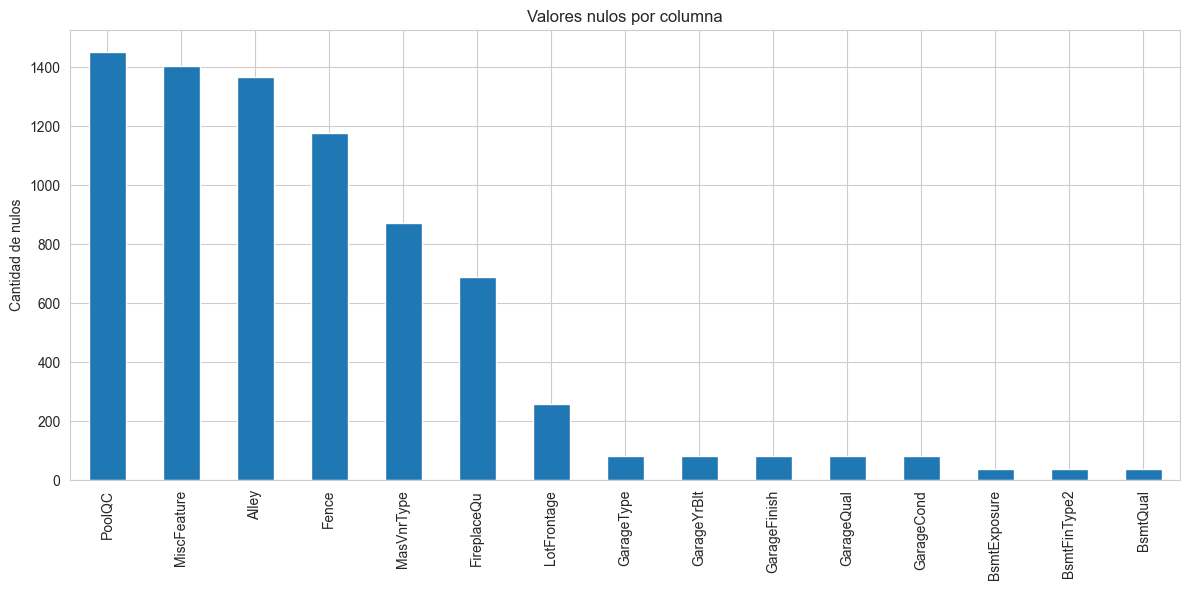

In [9]:
# Columnas con valores nulos
valores_nulos = df.isnull().sum()
valores_nulos = valores_nulos[valores_nulos > 0].sort_values(ascending=False)

print(f'Columnas con valores nulos: {len(valores_nulos)}')
print('\nTop 10 columnas con mas nulos:')
print(valores_nulos.head(10))

# Visualizar
plt.figure(figsize=(12, 6))
valores_nulos.head(15).plot(kind='bar')
plt.title('Valores nulos por columna')
plt.ylabel('Cantidad de nulos')
plt.tight_layout()
plt.show()

## 6. Correlaciones con el precio

Veamos que variables numericas tienen mayor correlacion con SalePrice.

Top 15 variables mas correlacionadas con SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


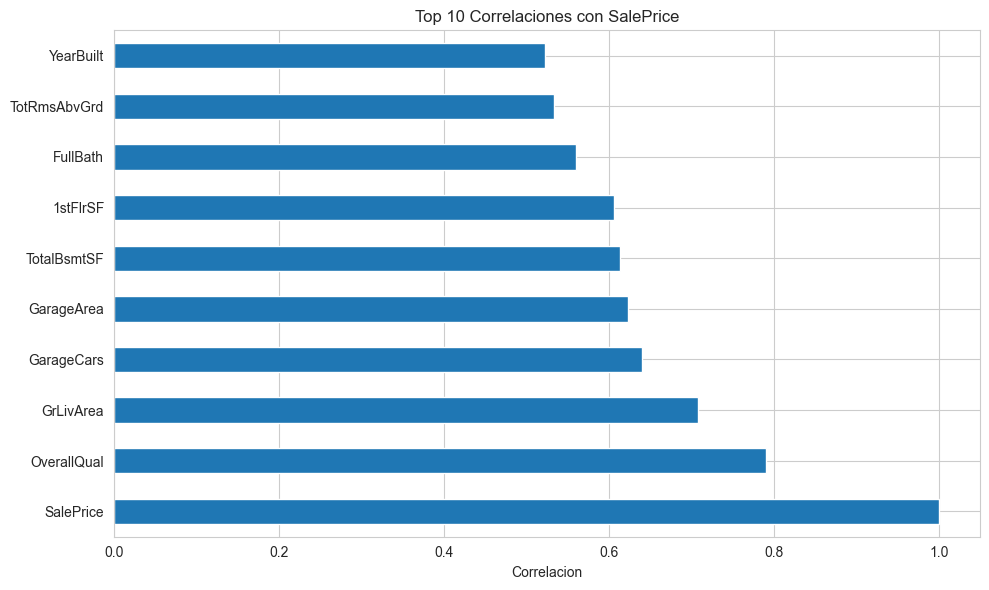

In [10]:
# Correlaciones con SalePrice
correlaciones = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

print('Top 15 variables mas correlacionadas con SalePrice:')
print(correlaciones.head(15))

# Visualizar top 10
plt.figure(figsize=(10, 6))
correlaciones.head(10).plot(kind='barh')
plt.title('Top 10 Correlaciones con SalePrice')
plt.xlabel('Correlacion')
plt.tight_layout()
plt.show()

## 7. Scatter plots de variables clave

Visualizamos las relaciones entre las variables mas importantes y el precio.

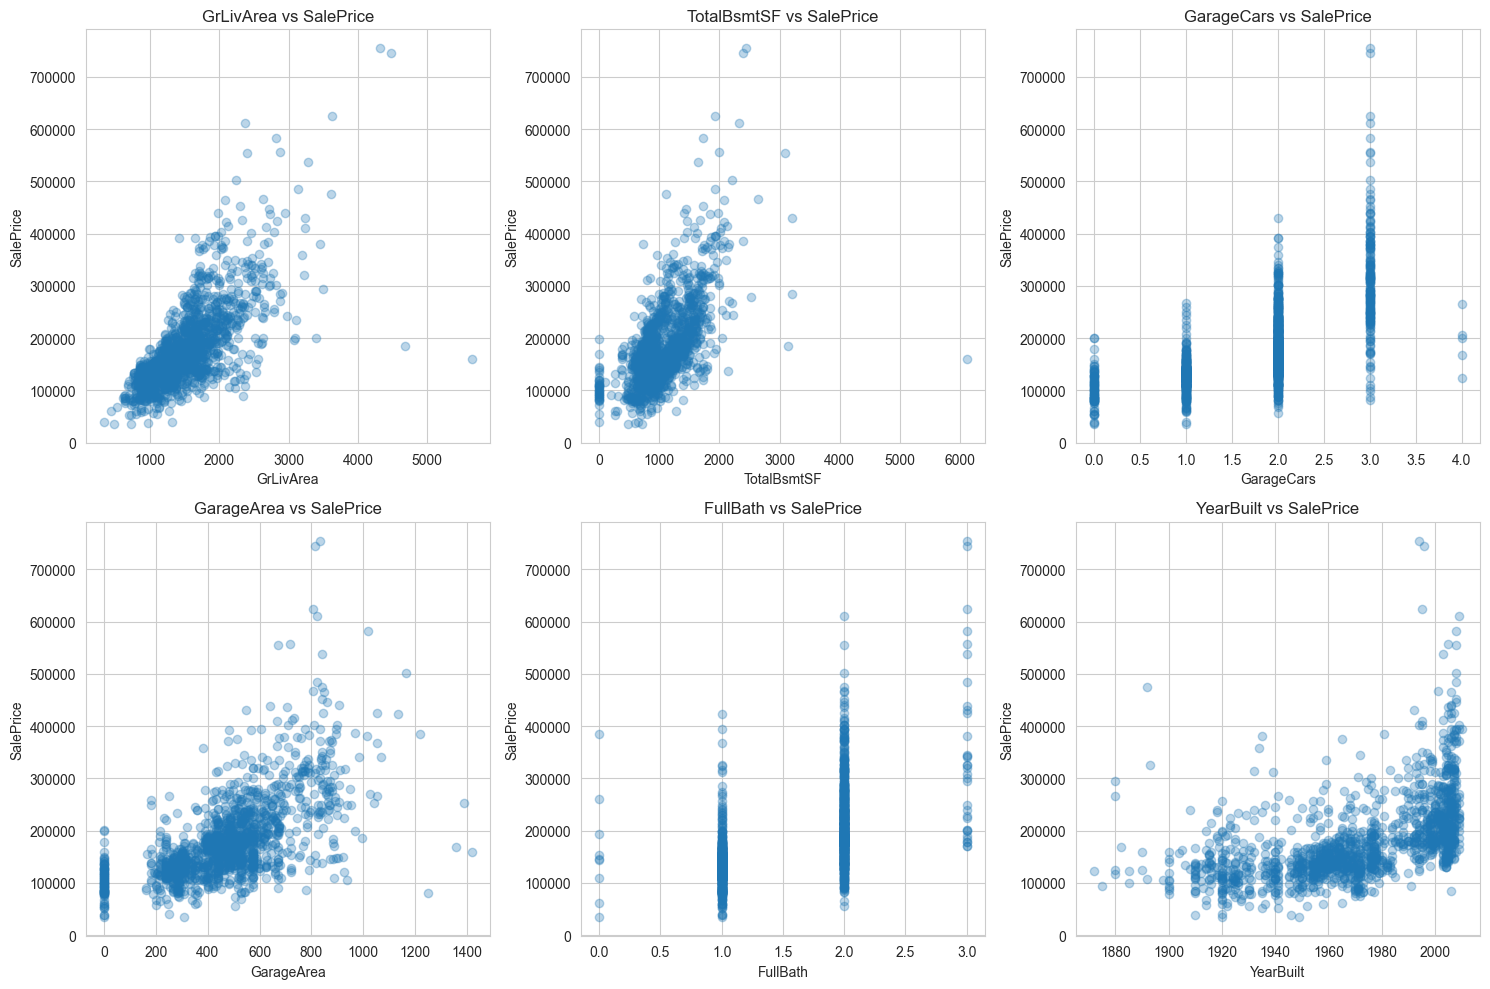

In [11]:
# Scatter plots de las variables mas correlacionadas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
variables_clave = ['GrLivArea', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'FullBath', 'YearBuilt']

for ax, var in zip(axes.flatten(), variables_clave):
    ax.scatter(df[var], df['SalePrice'], alpha=0.3)
    ax.set_xlabel(var)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{var} vs SalePrice')

plt.tight_layout()
plt.show()

## 8. Resumen de hallazgos

Escribe aqui tus conclusiones de la exploracion:
- Cuantos registros y variables tiene el dataset
- Cuales son las variables mas importantes para predecir el precio
- Cuantos valores faltantes hay y cuales columnas los tienen
- Que variables son numericas y cuales categoricas
- Cual es la distribucion del precio de venta

In [12]:
# Guardar un resumen para el equipo
resumen = {
    'total_registros': df.shape[0],
    'total_caracteristicas': df.shape[1],
    'variables_numericas': len(numericas),
    'variables_categoricas': len(categoricas),
    'columnas_con_nulos': len(valores_nulos),
    'precio_promedio': df['SalePrice'].mean(),
    'precio_mediana': df['SalePrice'].median()
}

print('RESUMEN DEL DATASET:')
print('=' * 40)
for key, value in resumen.items():
    print(f'{key}: {value}')

RESUMEN DEL DATASET:
total_registros: 1460
total_caracteristicas: 81
variables_numericas: 38
variables_categoricas: 43
columnas_con_nulos: 19
precio_promedio: 180921.19589041095
precio_mediana: 163000.0
